In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [42]:
# Load dataset
file_path = 'dataset_prediksi_bca.csv'
df = pd.read_csv(file_path)

# Tampilkan 5 data pertama
print(df.head())

      Tanggal  Harga_Tutup
0  2024-04-22  8590.541992
1  2024-04-23  8935.082031
2  2024-04-24  9141.806641
3  2024-04-25  8981.020508
4  2024-04-26  8843.205078


In [43]:
# Konversi ke datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

# Urutkan berdasarkan tanggal
df = df.sort_values('Tanggal')

# Set index
df.set_index('Tanggal', inplace=True)

In [44]:
print(df.isnull().sum())

Harga_Tutup    0
dtype: int64


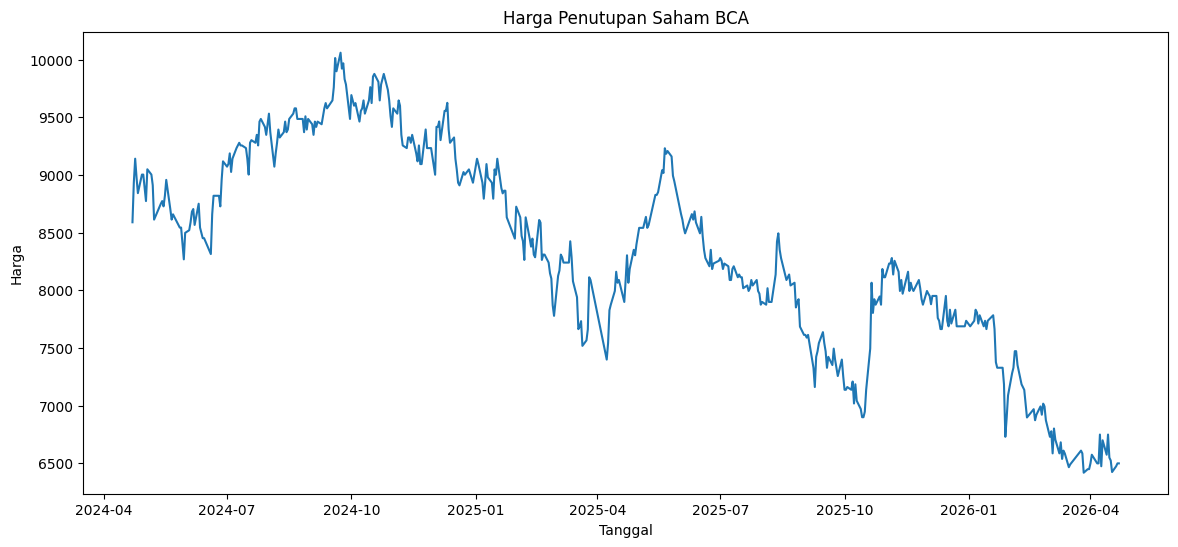

In [45]:
plt.figure(figsize=(14,6))
plt.plot(df['Harga_Tutup'])
plt.title('Harga Penutupan Saham BCA')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.show()

In [46]:
result = adfuller(df['Harga_Tutup'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -0.6310034979389385
p-value: 0.8638215066205683


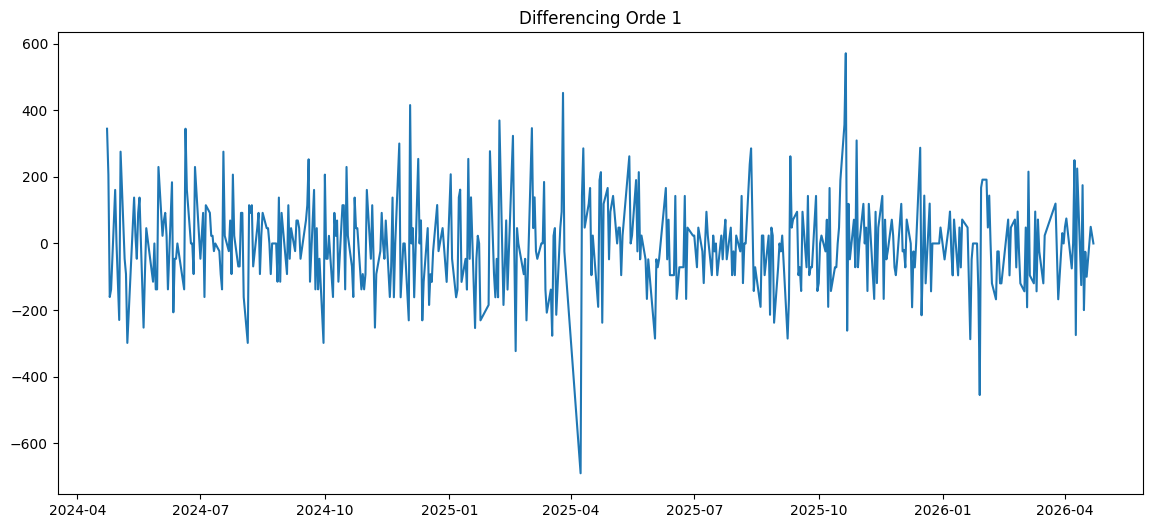

In [47]:
# Differencing orde 1
series_diff = df['Harga_Tutup'].diff().dropna()

# Plot hasil differencing
plt.figure(figsize=(14,6))
plt.plot(series_diff)
plt.title('Differencing Orde 1')
plt.show()

In [48]:
result_diff = adfuller(series_diff)

print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic: -18.33285332668505
p-value: 2.2540165028248112e-30


In [49]:
series = df['Harga_Tutup']

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print('Train:', len(train))
print('Test :', len(test))

Train: 380
Test : 96


In [50]:
import itertools

best_aic = np.inf
best_order = None
best_model = None

for p, q in itertools.product(range(0,6), range(0,6)):
    try:
        model = ARIMA(train, order=(p,1,q))
        result = model.fit()

        if result.aic < best_aic:
            best_aic = result.aic
            best_order = (p,1,q)
            best_model = result

    except:
        continue

print('Best Order:', best_order)
print('Best AIC:', best_aic)

Best Order: (4, 1, 2)
Best AIC: 4830.101461027847


In [51]:
model_final = ARIMA(train, order=(4,1,2))
model_final = model_final.fit()

print(model_final.summary())

                               SARIMAX Results                                
Dep. Variable:            Harga_Tutup   No. Observations:                  380
Model:                 ARIMA(4, 1, 2)   Log Likelihood               -2408.051
Date:                Sat, 23 May 2026   AIC                           4830.101
Time:                        10:14:22   BIC                           4857.664
Sample:                             0   HQIC                          4841.040
                                - 380                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0397      0.051    -20.229      0.000      -1.140      -0.939
ar.L2         -1.1960      0.064    -18.607      0.000      -1.322      -1.070
ar.L3         -0.2482      0.064     -3.857      0.0

In [52]:
forecast = model_final.forecast(steps=len(test))

In [53]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print('MAE :', mae)
print('RMSE:', rmse)

MAE : 816.3558419989864
RMSE: 982.2870416065393


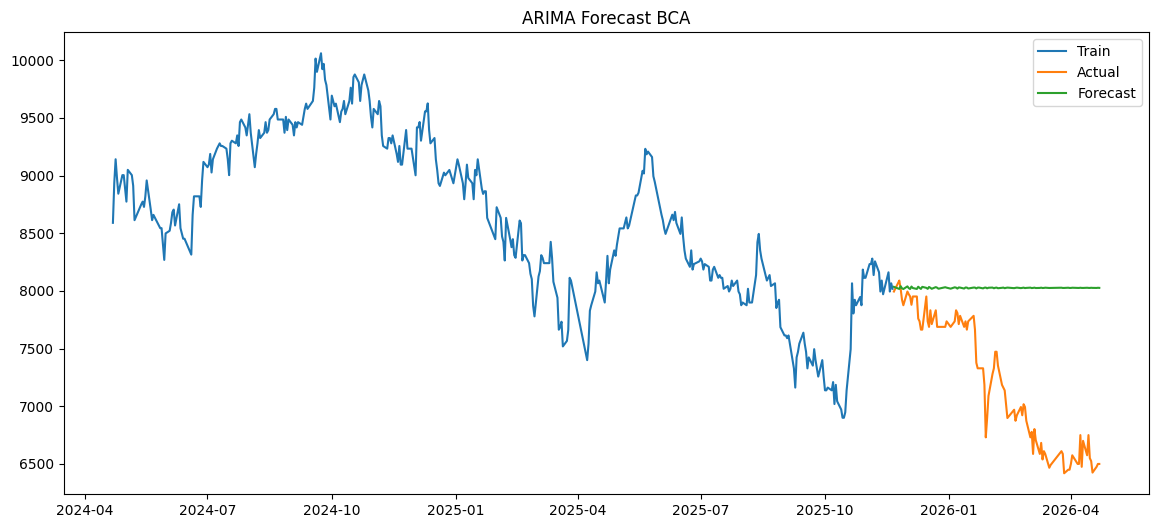

In [54]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title('ARIMA Forecast BCA')
plt.show()

In [55]:
from statsmodels.tsa.stattools import adfuller

# Melakukan uji stasioneritas Augmented Dickey-Fuller
print("Hasil Uji Dickey-Fuller:")
result = adfuller(df['Harga_Tutup'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print("\nKesimpulan: Data sudah stasioner (Tolak H0). Nilai d pada ARIMA bisa diset d=0.")
else:
    print("\nKesimpulan: Data belum stasioner (Gagal tolak H0). Perlu dilakukan differencing agar data stasioner (d > 0).")

Hasil Uji Dickey-Fuller:
ADF Statistic: -0.631003
p-value: 0.863822
Critical Values:
	1%: -3.444
	5%: -2.868
	10%: -2.570

Kesimpulan: Data belum stasioner (Gagal tolak H0). Perlu dilakukan differencing agar data stasioner (d > 0).


In [56]:
import itertools
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Mengabaikan pesan warning
warnings.filterwarnings("ignore")

# Menentukan jarak uji coba parameter p, d, q
p = range(0, 6) # Uji dari 0 sampai 5
d = range(1, 3) # Uji d=1 dan d=2 (karena data belum stasioner)
q = range(0, 6) # Uji dari 0 sampai 5

# Membuat semua kemungkinan kombinasi (p, d, q)
pdq = list(itertools.product(p, d, q))

best_aic = float("inf")
best_pdq = None

print("Sedang memproses pencarian parameter terbaik, mohon tunggu sebentar...")

for param in pdq:
    try:
        # Melatih model menggunakan kombinasi parameter saat ini
        model = ARIMA(df['Harga_Tutup'], order=param)
        results = model.fit()
        
        # Menyimpan parameter jika nilai AIC-nya lebih kecil (lebih baik)
        if results.aic < best_aic:
            best_aic = results.aic
            best_pdq = param
            
    except:
        continue

print("--------------------------------------------------")
print(f"Pencarian Selesai!")
print(f"Kombinasi Parameter ARIMA Terbaik (p, d, q) adalah: {best_pdq}")
print(f"Dengan nilai AIC terendah: {best_aic:.2f}")
print("--------------------------------------------------")

Sedang memproses pencarian parameter terbaik, mohon tunggu sebentar...
--------------------------------------------------
Pencarian Selesai!
Kombinasi Parameter ARIMA Terbaik (p, d, q) adalah: (4, 1, 2)
Dengan nilai AIC terendah: 6023.68
--------------------------------------------------


Jumlah Data Latih: 380
Jumlah Data Uji: 96

--- Evaluasi Kinerja Model ---
Mean Absolute Error (MAE): 816.36
Root Mean Squared Error (RMSE): 982.29


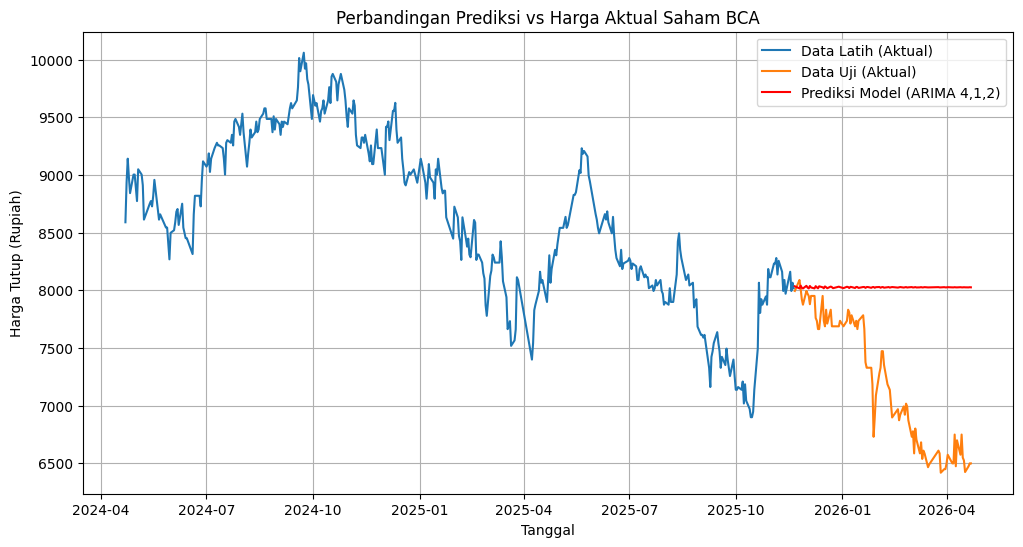

In [57]:
# Memisahkan data menjadi data latih (Training) dan data uji (Testing) - 80% Train, 20% Test
train_size = int(len(df) * 0.8)
train_data, test_data = df.iloc[:train_size], df.iloc[train_size:]

print(f"Jumlah Data Latih: {len(train_data)}")
print(f"Jumlah Data Uji: {len(test_data)}")

# Melatih model ARIMA dengan parameter terbaik (4, 1, 2)
model_terbaik = ARIMA(train_data['Harga_Tutup'], order=(4, 1, 2))
fitted_model = model_terbaik.fit()

# Melakukan prediksi untuk rentang waktu data uji
predictions = fitted_model.forecast(steps=len(test_data))
predictions.index = test_data.index

# Menghitung metrik evaluasi kinerja model
mae = mean_absolute_error(test_data['Harga_Tutup'], predictions)
mse = mean_squared_error(test_data['Harga_Tutup'], predictions)
rmse = np.sqrt(mse)

print("\n--- Evaluasi Kinerja Model ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Visualisasi Hasil Prediksi vs Harga Aktual
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Harga_Tutup'], label='Data Latih (Aktual)')
plt.plot(test_data.index, test_data['Harga_Tutup'], label='Data Uji (Aktual)')
plt.plot(predictions.index, predictions, color='red', label='Prediksi Model (ARIMA 4,1,2)')
plt.title('Perbandingan Prediksi vs Harga Aktual Saham BCA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Tutup (Rupiah)')
plt.legend()
plt.grid(True)
plt.show()

Memulai Rolling Forecast (menebak 1 hari ke depan, lalu update data)...
Proses ini akan memakan waktu lebih lama karena model dilatih ulang per harinya.

--- Evaluasi Kinerja Model (Rolling Forecast) ---
Mean Absolute Error (MAE) Baru: 95.14
Root Mean Squared Error (RMSE) Baru: 121.75


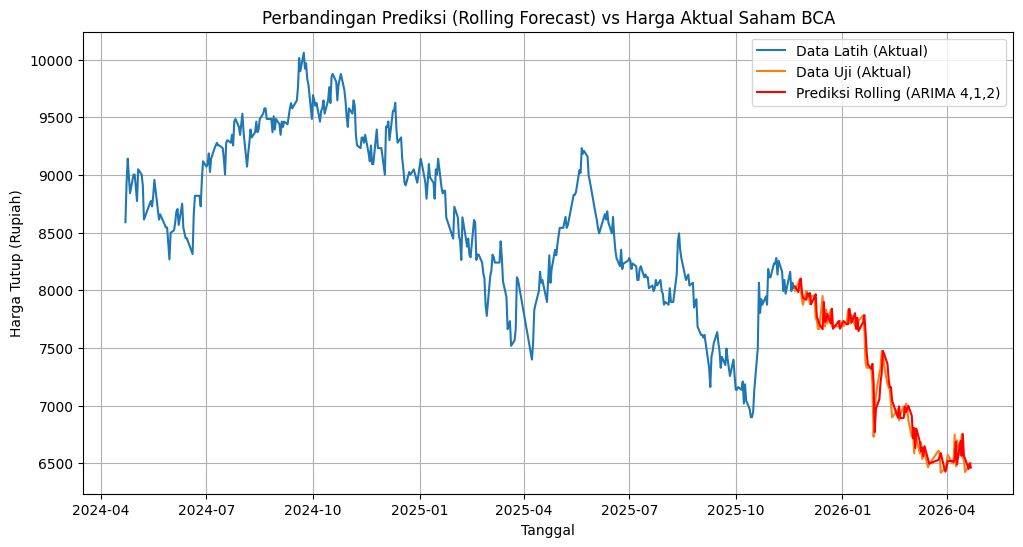

In [58]:
# Menyiapkan list data historis (dimulai dengan data latih)
history = [x for x in train_data['Harga_Tutup']]
predictions_rolling = []

print("Memulai Rolling Forecast (menebak 1 hari ke depan, lalu update data)...")
print("Proses ini akan memakan waktu lebih lama karena model dilatih ulang per harinya.")

# Lakukan perulangan untuk setiap data di data uji
for t in range(len(test_data)):
    # Mengabaikan pesan warning agar output bersih
    import warnings
    warnings.filterwarnings("ignore")
    
    # Latih model dengan data historis yang terus bertambah
    model = ARIMA(history, order=(4,1,2))
    model_fit = model.fit()
    
    # Tebak 1 langkah (hari) ke depan
    yhat = model_fit.forecast()[0]
    predictions_rolling.append(yhat)
    
    # Ambil nilai harga aktual sesungguhnya pada hari tersebut, dan masukkan ke 'history' 
    # sebagai modal belajar tambahan untuk tebakan hari esoknya
    obs = test_data['Harga_Tutup'].iloc[t]
    history.append(obs)

# Menghitung metrik evaluasi kinerja model baru
mae_rolling = mean_absolute_error(test_data['Harga_Tutup'], predictions_rolling)
mse_rolling = mean_squared_error(test_data['Harga_Tutup'], predictions_rolling)
rmse_rolling = np.sqrt(mse_rolling)

print("\n--- Evaluasi Kinerja Model (Rolling Forecast) ---")
print(f"Mean Absolute Error (MAE) Baru: {mae_rolling:.2f}")
print(f"Root Mean Squared Error (RMSE) Baru: {rmse_rolling:.2f}")

# Ubah hasil list tebakan menjadi urutan Series ber-index tanggal
import pandas as pd
predictions_series = pd.Series(predictions_rolling, index=test_data.index)

# Visualisasi Hasil Prediksi Rolling vs Harga Aktual
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['Harga_Tutup'], label='Data Latih (Aktual)')
plt.plot(test_data.index, test_data['Harga_Tutup'], label='Data Uji (Aktual)')
plt.plot(predictions_series.index, predictions_series, color='red', label='Prediksi Rolling (ARIMA 4,1,2)')
plt.title('Perbandingan Prediksi (Rolling Forecast) vs Harga Aktual Saham BCA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Tutup (Rupiah)')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
import json
import os

# Memastikan folder tujuan ada
if not os.path.exists('website_prediksi_bca'):
    os.makedirs('website_prediksi_bca')

# Mengambil data 100 hari terakhir dari data uji (agar grafik terlihat manis)
display_len = min(len(test_data), 100)
labels_list = test_data.index[-display_len:].astype(str).tolist()
actual_list = test_data['Harga_Tutup'].iloc[-display_len:].tolist()
predicted_list = predictions_series.iloc[-display_len:].tolist()

js_content = f"""// File ini dibuat otomatis dari Python Notebook
const chartData = {{
    labels: {json.dumps(labels_list)},
    actual: {json.dumps(actual_list)},
    predicted: {json.dumps(predicted_list)}
}};
"""

# Menyimpan data langsung ke folder website
with open('website_prediksi_bca/data.js', 'w') as f:
    f.write(js_content)
    
print("File data.js berhasil diekspor ke folder website_prediksi_bca!")

File data.js berhasil diekspor ke folder website_prediksi_bca!
